In [16]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('../nr_ic_merged.csv')

In [18]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [19]:
FPSIZE = 2048
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [21]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [22]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [23]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

kf = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [24]:
from sklearn.metrics import roc_auc_score

auc_per_fold = []

for train_index, test_index in kf.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=50,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    )

    # Train
    model.fit(X_train, y_train)

    # Predict probabilities
    y_pred_prob_list = model.predict_proba(X_test)
    y_pred_prob_matrix = np.column_stack(y_pred_prob_list).T

    # Compute ROC-AUC per target
    roc_auc_per_target = [
        roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
        for i in range(y.shape[1])
    ]

    auc_per_fold.append(roc_auc_per_target)

# Convert to array for easier statistics
auc_per_fold = np.array(auc_per_fold)

# Mean and std per target
mean_auc = np.mean(auc_per_fold, axis=0)
std_auc = np.std(auc_per_fold, axis=0)

print("Mean ROC-AUC per target:", mean_auc)
print("Std ROC-AUC per target:", std_auc)
print("Overall mean ROC-AUC:", np.mean(mean_auc))

Mean ROC-AUC per target: [0.98007119 0.98621247 0.9790167  0.98941545 0.98193759 0.96595279]
Std ROC-AUC per target: [0.00755898 0.00319932 0.00624486 0.00420306 0.01106814 0.01315603]
Overall mean ROC-AUC: 0.9804343629158252


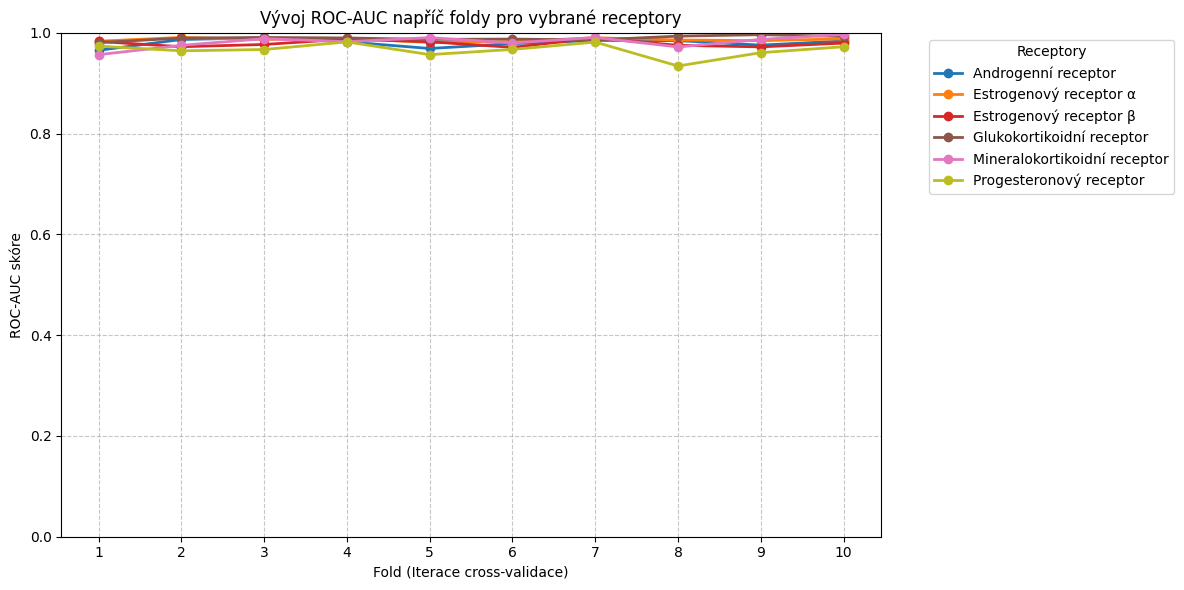

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Předpokládám, že proměnné 'auc_per_fold' a 'target_names' jsou již definovány z předchozího kroku.
# Například:
# auc_per_fold = np.random.uniform(0.7, 0.9, (5, 6))  # Příklad dat (5 foldů, 6 targetů)
# target_names = ["AR", "ERa", "ERb", "GR", "MR", "PR"]

num_folds = auc_per_fold.shape[0]
target_indices = [0, 1, 2, 3, 4, 5]  # Indexy targetů, které chceme vykreslit

# Slovník pro překlad (převzato z druhého skriptu)
czech_names = {
    "ar": "Androgenní receptor",
    "pr": "Progesteronový receptor",
    "gr": "Glukokortikoidní receptor",
    "mr": "Mineralokortikoidní receptor",
    "era": "Estrogenový receptor α",
    "erb": "Estrogenový receptor β"
}

# Nastavení barevné palety (stejné jako ve druhém skriptu)
cmap = matplotlib.colormaps.get_cmap('tab10')
n_targets_total = len(target_names) # Pro konzistenci barev

fig, ax = plt.subplots(figsize=(12, 6))

x_folds = np.arange(1, num_folds + 1)

for target_idx in target_indices:
    # Získání původního názvu a jeho překlad
    original_name = target_names[target_idx]
    label_name = czech_names.get(original_name.lower(), original_name)

    # Výběr barvy podle indexu (aby barva receptoru byla stejná v obou grafech)
    color = cmap(target_idx / n_targets_total)

    ax.plot(
        x_folds,
        auc_per_fold[:, target_idx],
        label=label_name,
        color=color,
        marker='o',  # Přidal jsem body pro lepší čitelnost jednotlivých foldů
        linewidth=2
    )

# Nastavení popisků v češtině
ax.set_xlabel("Fold (Iterace cross-validace)")
ax.set_ylabel("ROC-AUC skóre")
ax.set_title("Vývoj ROC-AUC napříč foldy pro vybrané receptory")

ax.set_ylim(0, 1.0)

# Vynucení celých čísel na ose X (1, 2, 3...)
ax.set_xticks(x_folds)

# Legenda
ax.legend(title="Receptory", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Uložení do SVG
# Ujistěte se, že složka 'images' existuje, nebo ji změňte podle potřeby
fig.savefig("images/rf_roc_auc_folds.svg", format="svg", bbox_inches="tight")

plt.show()